In [ ]:
# Run these command one time before Runtime Crash, then comment it out
# !pip uninstall numpy gensim scipy
# !pip install "numpy<2.0" "scipy<1.14.0" gensim
# import os
# os.kill(os.getpid(), 9)

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Would remove:
    /usr/local/bin/f2py
    /usr/local/bin/numpy-config
    /usr/local/lib/python3.11/dist-packages/numpy-2.0.2.dist-info/*
    /usr/local/lib/python3.11/dist-packages/numpy.libs/libgfortran-040039e1-0352e75f.so.5.0.0
    /usr/local/lib/python3.11/dist-packages/numpy.libs/libquadmath-96973f99-934c22de.so.0.0.0
    /usr/local/lib/python3.11/dist-packages/numpy.libs/libscipy_openblas64_-99b71e71.so
    /usr/local/lib/python3.11/dist-packages/numpy/*
Proceed (Y/n)? y
  Successfully uninstalled numpy-2.0.2
Found existing installation: scipy 1.15.3
Uninstalling scipy-1.15.3:
  Would remove:
    /usr/local/lib/python3.11/dist-packages/scipy-1.15.3.dist-info/*
    /usr/local/lib/python3.11/dist-packages/scipy.libs/libgfortran-040039e1-0352e75f.so.5.0.0
    /usr/local/lib/python3.11/dist-packages/scipy.libs/libgfortran-040039e1.so.5.0.0
    /usr/local/lib/python3.11/dist-packages/scipy.libs/libquadmath-96973f99-

In [ ]:
#!python -m spacy download "en_core_web_lg"
import gensim.downloader as api
wv = api.load('word2vec-google-news-300')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 917.2 kB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy
import pandas as pd
import seaborn as sn
import numpy as np
from sklearn.model_selection import train_test_split
from  sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.ensemble import GradientBoostingClassifier
from matplotlib import pyplot as plt
nlp = spacy.load("en_core_web_lg")
def preprocess_and_vectorize(text):
    doc = nlp(text)
    filtered_tokens = []
    for token in doc:
        if token.is_stop or token.is_punct:
            continue
        filtered_tokens.append(token.lemma_)
    return wv.get_mean_vector(filtered_tokens)
dft = pd.read_csv("18) fake_news.csv", nrows = 1000)
dff = pd.read_csv("19) true_news.csv", nrows = 1000)
dft["output"] = "True"
dff["output"] = "False"
df = pd.concat([dft,dff])
df.drop(["title", "subject","date"], axis=1, inplace=True)
df.reset_index(drop=True, inplace=True)
df["vector"] = df['text'].apply(lambda x: preprocess_and_vectorize(x))
df.drop(["text"], axis=1, inplace=True)
print(df["output"].value_counts())
x_train, x_test, y_train, y_test = train_test_split(df.vector.values, df.output, test_size=0.2, random_state=45)
x_train_2d = np.stack(x_train)
x_test_2d = np.stack(x_test)
df

output
True     1000
False    1000
Name: count, dtype: int64


,output,vector
0,True,"[0.0074407714, 0.021954956, -0.0035027957, 0.0..."
1,True,"[-0.0009021067, 0.012329693, -0.0043598576, 0...."
2,True,"[0.010802238, 0.01481041, -0.004953617, 0.0107..."
3,True,"[0.0058394885, 0.011465134, -0.0009828347, 0.0..."
4,True,"[0.020385195, 0.0177241, 0.0070382026, 0.02907..."
...,...,...
1995,False,"[-0.0024448542, -0.0029659253, 8.8445966e-05, ..."
1996,False,"[0.007847815, 0.007863032, 0.0070896023, 0.019..."
1997,False,"[0.0015807514, 0.012843673, 0.015964253, 0.013..."
1998,False,"[0.014518995, 0.014974172, -6.523747e-05, 0.00..."


In [ ]:
clf = GradientBoostingClassifier()
clf.fit(x_train_2d, y_train)
y_pred = clf.predict(x_test_2d)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

       False       0.94      0.98      0.96       192
        True       0.98      0.95      0.96       208

    accuracy                           0.96       400
   macro avg       0.96      0.96      0.96       400
weighted avg       0.96      0.96      0.96       400



Text(95.72222222222221, 0.5, 'Truth')

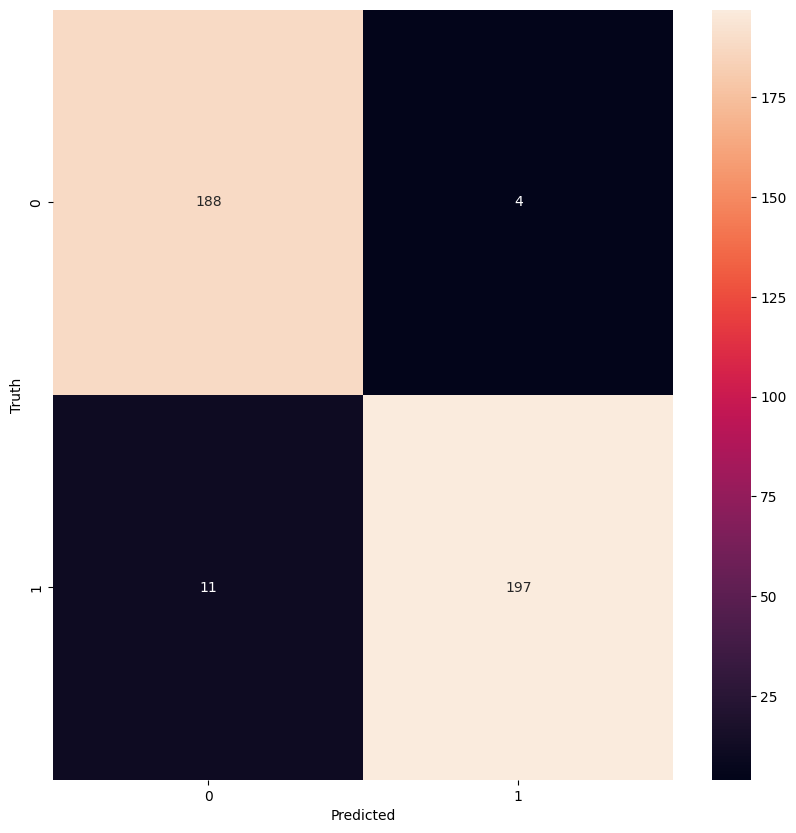

In [ ]:
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(10,10))
sn.heatmap(cm, annot=True, fmt="d")
plt.xlabel('Predicted')
plt.ylabel('Truth')